# Matrix Factorizations & Solving Linear Systems

### LU · QR · Cholesky — and how to solve *square*, *over-determined*, and *under-determined* systems

Almost every quantitative method you will ever touch — linear regression, portfolio
optimization, Kalman filters, Gaussian processes, PCA — eventually boils down to one
humble question:

$$\textbf{Given a matrix } A \textbf{ and a vector } b,\ \text{find } x \text{ such that } A x = b.$$

This notebook builds the machinery to answer that question **from first principles**.
We will:

1. See *why* we factor a matrix instead of inverting it.
2. Build **LU**, **Cholesky**, and **QR** factorizations from scratch with numpy.
3. Use them to solve three flavours of linear systems:
   - **Square** ($A$ is $n\times n$, exactly one solution),
   - **Over-determined** ($A$ is tall — more equations than unknowns → *least-squares*),
   - **Under-determined** ($A$ is wide — more unknowns than equations → *least-norm*).
4. Understand *numerical conditioning* — why some "correct" methods give garbage answers.

> 🎯 **Quant-interview lens.** Throughout, I'll flag the spots interviewers love to
> probe. As a teaser, the single most common one: *"How would you solve a least-squares
> problem, and why is solving the normal equations a bad idea numerically?"* — you'll be
> able to answer that cold by the end.

---

## 0 · Setup

We only need `numpy` for the linear algebra and `matplotlib` for pictures. We'll lean on
`scipy`/`numpy`'s built-in factorizations *only* to check our from-scratch versions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = {
    "blue":   "steelblue",
    "red":    "tomato",
    "green":  "mediumseagreen",
    "orange": "darkorange",
    "navy":   "navy",
}
print("Ready.")

Ready.


---
## 1 · Why factorize at all?

The naïve way to solve $Ax = b$ is to compute the inverse and multiply:

$$x = A^{-1} b.$$

**Don't do this.** Computing $A^{-1}$ is *more* work than solving the system, it's
numerically less stable, and you almost never actually need the inverse itself — you
need the *solution*.

The smarter idea: **factor $A$ into a product of matrices that are trivially easy to
solve with.** The all-star "easy" matrices are **triangular** ones, because they unwind
with simple substitution (next section).

$$A = \underbrace{L}_{\text{lower-tri}}\,\underbrace{U}_{\text{upper-tri}}
\qquad\Longrightarrow\qquad
\underbrace{Ax=b}_{\text{hard}} \;\Leftrightarrow\;
\underbrace{Ly=b,\quad Ux=y}_{\text{two easy triangular solves}}$$

> **Key insight:** A factorization is a *one-time investment*. Factoring costs
> $\mathcal{O}(n^3)$, but once you have it, **each** new right-hand side $b$ costs only
> $\mathcal{O}(n^2)$ to solve. If you must solve $Ax=b_1,\,Ax=b_2,\dots$ for many $b$'s
> (think: re-running a regression as new data streams in), you factor **once** and reuse.

| Symbol | Meaning |
|---|---|
| $A$ | the coefficient matrix ($m \times n$) |
| $x$ | the unknown vector we want |
| $b$ | the right-hand side (the "answer" the equations must hit) |
| $L$ | lower-triangular matrix (zeros above the diagonal) |
| $U$ | upper-triangular matrix (zeros below the diagonal) |
| $Q$ | orthogonal matrix ($Q^\top Q = I$) — a rotation/reflection |
| $R$ | upper-triangular matrix (from QR) |

> 🎯 **Quant reminder.** "Why not just invert the matrix?" is a classic warm-up. The
> crisp answer: *inversion is wasteful and unstable; factor-and-solve is cheaper, reusable,
> and better conditioned.*

---

## 2 · The payoff: triangular systems solve themselves

Why are triangular matrices the heroes? Because you can solve them by **substitution** —
no fancy algorithm, just bookkeeping.

**Forward substitution** (lower-triangular $Ly = b$). The first equation involves only
$y_1$, so solve it. The second involves $y_1, y_2$ — but you already know $y_1$, so solve
for $y_2$. Cascade downward:

$$y_i = \frac{1}{L_{ii}}\left(b_i - \sum_{j<i} L_{ij}\,y_j\right).$$

**Back substitution** (upper-triangular $Ux = y$) is the same idea, but you start from the
*bottom* row (which involves only $x_n$) and climb up:

$$x_i = \frac{1}{U_{ii}}\left(y_i - \sum_{j>i} U_{ij}\,x_j\right).$$

> **Key insight:** Think of it like a staircase. A triangular system gives you one step
> you can stand on immediately ($y_1$ or $x_n$), and every subsequent step only depends on
> the ones you've already climbed. No step is ever "circular."

Let's implement both — these are the workhorses every factorization will call.

In [2]:
def forward_sub(L, b):
    '''Solve L y = b for lower-triangular L.'''
    n = L.shape[0]
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    return y

def back_sub(U, b):
    '''Solve U x = b for upper-triangular U.'''
    n = U.shape[0]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - U[i, i+1:] @ x[i+1:]) / U[i, i]
    return x

# quick sanity check
L = np.array([[2., 0, 0], [3, 1, 0], [1, -1, 4]])
b = np.array([4., 5., 6.])
y = forward_sub(L, b)
print("forward_sub solution :", y)
print("residual ||Ly - b||  :", np.linalg.norm(L @ y - b))

forward_sub solution : [ 2.   -1.    0.75]
residual ||Ly - b||  : 0.0


---
## 3 · LU factorization — Gaussian elimination, remembered

You already know Gaussian elimination: add multiples of one row to another to zero out
the entries below the diagonal, turning $A$ into an upper-triangular $U$. The trick of
**LU** is to *remember the multipliers you used* — those multipliers, stacked into a
lower-triangular matrix $L$, exactly undo the elimination.

$$A = L\,U,\qquad
L = \begin{bmatrix} 1 & & \\ \ell_{21} & 1 & \\ \ell_{31} & \ell_{32} & 1\end{bmatrix},\quad
U = \begin{bmatrix} * & * & * \\ & * & * \\ & & *\end{bmatrix}.$$

The multiplier $\ell_{ij} = (\text{entry to kill}) / (\text{pivot})$ is "how much of row
$j$ I subtracted from row $i$." $L$ is literally a *receipt* of the elimination steps.

### Pivoting — the stability fix

If a pivot is zero (or tiny), dividing by it explodes. The fix: **swap rows** so the
largest-magnitude entry in the column becomes the pivot. This row-swapping is recorded in
a permutation matrix $P$, giving the practical factorization

$$P A = L U.$$

> **Key insight:** Pivoting isn't about correctness on paper — it's about *floating-point
> survival*. Dividing by a tiny pivot amplifies rounding error catastrophically. Always
> pivot.

> 🎯 **Quant reminder.** Be ready to explain *why* partial pivoting exists ("to avoid
> dividing by tiny pivots and blowing up roundoff") and to state the cost: LU is
> $\tfrac{2}{3}n^3$ flops.

In [3]:
def lu_factor(A):
    '''LU with partial pivoting: returns P, L, U with P @ A = L @ U.'''
    A = A.astype(float).copy()
    n = A.shape[0]
    L = np.eye(n)
    P = np.eye(n)
    for k in range(n):
        # --- partial pivot: largest |entry| in column k at/below the diagonal
        piv = k + np.argmax(np.abs(A[k:, k]))
        if piv != k:
            A[[k, piv]] = A[[piv, k]]
            P[[k, piv]] = P[[piv, k]]
            L[[k, piv], :k] = L[[piv, k], :k]   # swap already-computed multipliers
        # --- eliminate below the pivot, recording multipliers in L
        for i in range(k + 1, n):
            L[i, k] = A[i, k] / A[k, k]
            A[i, k:] -= L[i, k] * A[k, k:]
    return P, L, np.triu(A)

A = rng.normal(size=(4, 4))
P, L, U = lu_factor(A)
print("max |P A - L U| :", np.abs(P @ A - L @ U).max())
print("L lower-tri?    :", np.allclose(L, np.tril(L)))
print("U upper-tri?    :", np.allclose(U, np.triu(U)))

max |P A - L U| : 1.1102230246251565e-16
L lower-tri?    : True
U upper-tri?    : True


### Solving a square system with LU

To solve $Ax=b$: apply the same row swaps to $b$ (i.e. $Pb$), then do the two triangular
solves. Let's also use LU to grab the **determinant** for free — it's just the product of
$U$'s diagonal (times the sign of the permutation).

In [4]:
def lu_solve(A, b):
    P, L, U = lu_factor(A)
    y = forward_sub(L, P @ b)   # L y = P b
    x = back_sub(U, y)          # U x = y
    return x

A = rng.normal(size=(5, 5))
b = rng.normal(size=5)
x = lu_solve(A, b)

print("our LU solve     :", x)
print("np.linalg.solve  :", np.linalg.solve(A, b))
print("max abs diff     :", np.abs(x - np.linalg.solve(A, b)).max())

# determinant via LU: det(A) = det(P)^-1 * prod(diag(U))
P, L, U = lu_factor(A)
sign = np.linalg.det(P)              # +-1
det_lu = sign * np.prod(np.diag(U))
print("\ndet via LU       :", det_lu)
print("np.linalg.det    :", np.linalg.det(A))

our LU solve     : [-0.3856 -1.0144 -1.7677  1.8432  1.6396]
np.linalg.solve  : [-0.3856 -1.0144 -1.7677  1.8432  1.6396]
max abs diff     : 6.661338147750939e-16

det via LU       : -1.390196928627888
np.linalg.det    : -1.3901969286278877


---
## 4 · Cholesky — LU's faster cousin for symmetric positive-definite matrices

Many matrices in quant finance are **symmetric positive-definite (SPD)**: covariance
matrices, Gram matrices $A^\top A$, kernel matrices. SPD means symmetric *and* $x^\top M x > 0$
for every nonzero $x$ (geometrically: the quadratic bowl $x^\top M x$ opens strictly
upward in every direction).

For SPD matrices we can do better than LU. **Cholesky** writes

$$M = L L^\top,$$

a single lower-triangular factor and its transpose — so we store/compute *half* of LU.
It's about **2× faster** ($\tfrac{1}{3}n^3$ flops) and very stable (no pivoting needed).

The entries come from matching $M = LL^\top$ term by term:

$$L_{jj} = \sqrt{\,M_{jj} - \sum_{k<j} L_{jk}^2\,},
\qquad
L_{ij} = \frac{1}{L_{jj}}\Big(M_{ij} - \sum_{k<j} L_{ik} L_{jk}\Big)\ \ (i>j).$$

> **Key insight — the cheapest positive-definiteness test there is.** That square root
> only works if its argument is positive. If Cholesky ever tries to take $\sqrt{\text{negative}}$,
> the matrix is **not** positive-definite. So "does Cholesky succeed?" *is* the PD test —
> and it's cheaper than computing eigenvalues.

> 🎯 **Quant reminder.** *"How do you check if a matrix is positive-definite?"* and
> *"How do you sample correlated Gaussians?"* are extremely common. Answer to the second:
> Cholesky-factor the covariance $\Sigma = LL^\top$, draw i.i.d. standard normals $z$, then
> $x = Lz$ has covariance $\Sigma$. We demo this below.

In [5]:
def cholesky(M):
    '''Cholesky factor of SPD matrix: returns lower L with M = L L^T.'''
    n = M.shape[0]
    L = np.zeros_like(M, dtype=float)
    for j in range(n):
        s = M[j, j] - L[j, :j] @ L[j, :j]
        if s <= 0:
            raise np.linalg.LinAlgError("matrix is not positive-definite")
        L[j, j] = np.sqrt(s)
        for i in range(j + 1, n):
            L[i, j] = (M[i, j] - L[i, :j] @ L[j, :j]) / L[j, j]
    return L

# build a guaranteed-SPD matrix:  M = B B^T + I
B = rng.normal(size=(4, 4))
M = B @ B.T + np.eye(4)
L = cholesky(M)
print("max |L L^T - M|  :", np.abs(L @ L.T - M).max())
print("matches numpy?   :", np.allclose(L, np.linalg.cholesky(M)))

# the PD test in action
try:
    cholesky(np.array([[1., 2.], [2., 1.]]))   # eigenvalues 3 and -1 -> NOT PD
except np.linalg.LinAlgError as e:
    print("non-PD correctly rejected:", e)

max |L L^T - M|  : 1.7763568394002505e-15
matches numpy?   : True
non-PD correctly rejected: matrix is not positive-definite


### Cholesky in action: sampling correlated normals

We want draws from $\mathcal{N}(0, \Sigma)$ for a target correlation $\Sigma$. Recipe:
factor $\Sigma = LL^\top$, then transform standard-normal noise $z$ via $x = Lz$. Let's
verify the empirical covariance comes back to $\Sigma$.

target Sigma:
 [[1.  0.8]
 [0.8 1. ]]

empirical cov:
 [[0.9922 0.7953]
 [0.7953 1.0031]]


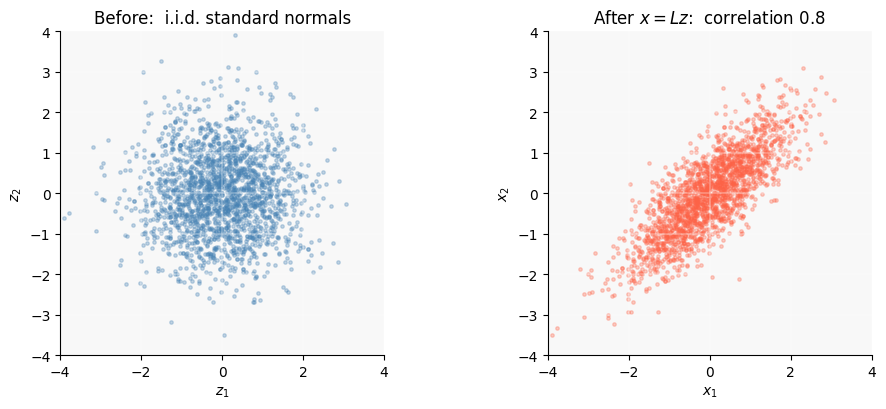

In [6]:
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.0]])
L = cholesky(Sigma)

z = rng.normal(size=(2, 20000))   # i.i.d. standard normals, columns are samples
x = L @ z                         # correlated samples

emp = np.cov(x)
print("target Sigma:\n", Sigma)
print("\nempirical cov:\n", emp)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
ax[0].scatter(z[0, :2000], z[1, :2000], s=6, alpha=0.3, color=PALETTE["blue"])
ax[0].set(title="Before:  i.i.d. standard normals", xlabel="$z_1$", ylabel="$z_2$",
          xlim=(-4, 4), ylim=(-4, 4))
ax[1].scatter(x[0, :2000], x[1, :2000], s=6, alpha=0.3, color=PALETTE["red"])
ax[1].set(title=r"After $x=Lz$:  correlation $0.8$", xlabel="$x_1$", ylabel="$x_2$",
          xlim=(-4, 4), ylim=(-4, 4))
for a in ax: a.grid(alpha=0.3); a.set_aspect("equal")
plt.tight_layout(); plt.show()

---
## 5 · QR decomposition — straightening the columns

LU and Cholesky are great for *square* systems. But the real workhorse for
*least-squares* (tall matrices) is **QR**:

$$A = Q R,\qquad Q^\top Q = I\ \text{(orthonormal columns)},\quad R\ \text{upper-triangular}.$$

The idea: take $A$'s columns, which point in arbitrary directions, and build an
**orthonormal basis** $Q$ for the same space — directions that are all unit-length and
mutually perpendicular. $R$ records "how to rebuild the original columns from the
orthonormal ones."

### Gram–Schmidt — the intuition

Process the columns left to right. For each new column $a_j$:
1. **Subtract off** its shadow (projection) onto every direction we've already locked in.
   What's left, $v_j$, is the part of $a_j$ that is genuinely *new* — perpendicular to all
   previous directions.
2. **Normalize** $v_j$ to unit length → that's $q_j$.

$$v_j = a_j - \sum_{i<j} \underbrace{(q_i^\top a_j)}_{R_{ij}}\,q_i,
\qquad q_j = \frac{v_j}{\|v_j\|},\qquad R_{jj} = \|v_j\|.$$

> **Key insight:** $q_i^\top a_j$ is the length of $a_j$'s shadow on direction $q_i$.
> Subtracting all those shadows leaves only the component pointing in a brand-new
> direction. That's why $Q$'s columns end up perpendicular.

We use the **modified** Gram–Schmidt below — algebraically identical but numerically far
more stable (it subtracts each projection immediately rather than all at once).

> 🎯 **Quant reminder.** Why is $Q$ being orthogonal so valuable? Because orthogonal
> matrices *preserve length* ($\|Qx\| = \|x\|$) — they don't amplify error. That's the
> deep reason QR-based least-squares beats the normal equations (Section 9).

In [7]:
def qr_gram_schmidt(A):
    '''Reduced QR via modified Gram-Schmidt: A (m x n) = Q (m x n) R (n x n).'''
    A = A.astype(float).copy()
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ v      # shadow length on q_i
            v -= R[i, j] * Q[:, i]     # subtract that shadow
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R

A = rng.normal(size=(6, 4))
Q, R = qr_gram_schmidt(A)
print("max |Q R - A|        :", np.abs(Q @ R - A).max())
print("Q^T Q = I ? (max dev):", np.abs(Q.T @ Q - np.eye(4)).max())
print("R upper-tri?         :", np.allclose(R, np.triu(R)))

max |Q R - A|        : 2.220446049250313e-16
Q^T Q = I ? (max dev): 2.220446049250313e-16
R upper-tri?         : True


---
## 6 · Square systems: which factorization should I reach for?

For a square, invertible $A$, all three can solve $Ax=b$. The choice is about *structure*
and *cost*:

| Situation | Use | Cost | Why |
|---|---|---|---|
| Generic square matrix | **LU** (with pivoting) | $\tfrac{2}{3}n^3$ | the default; handles any invertible $A$ |
| Symmetric positive-definite | **Cholesky** | $\tfrac{1}{3}n^3$ | 2× faster, very stable, no pivoting |
| Need max stability / ill-conditioned | **QR** | $\tfrac{4}{3}n^3$ | orthogonal $Q$ doesn't amplify error |

Solving with QR is a one-liner once you have it: $Ax=b \Rightarrow QRx=b \Rightarrow
Rx = Q^\top b$ (back-substitution), using $Q^{-1}=Q^\top$.

In [8]:
def qr_solve(A, b):
    Q, R = qr_gram_schmidt(A)
    return back_sub(R, Q.T @ b)

A = rng.normal(size=(5, 5))
b = rng.normal(size=5)
ref = np.linalg.solve(A, b)
print("LU  vs reference, max diff:", np.abs(lu_solve(A, b) - ref).max())
print("QR  vs reference, max diff:", np.abs(qr_solve(A, b) - ref).max())

LU  vs reference, max diff: 8.881784197001252e-16
QR  vs reference, max diff: 2.220446049250313e-15


---
## 7 · Over-determined systems → **least squares**

Now the tall case: $A$ is $m \times n$ with $m > n$ (more equations than unknowns). Think
**linear regression**: $m$ data points, $n$ features, and no straight line passes through
all the points exactly. There is *no* $x$ with $Ax = b$ — the system is over-determined.

So we change the goal from "hit $b$ exactly" to "**get as close as possible**":

$$\hat{x} = \arg\min_x \;\mathcal{L}(x),\qquad \mathcal{L}(x) = \|A x - b\|_2^2.$$

We minimize the *squared* length of the residual $r = Ax - b$ (the gap between our
prediction $Ax$ and the target $b$).

### The geometry (this is the whole idea)

$Ax$ can only ever land in the **column space** of $A$ — the flat subspace spanned by
$A$'s columns. $b$ generally sticks out of that subspace. The closest point in the
subspace to $b$ is its **orthogonal projection**. So the best residual must be
*perpendicular* to the column space:

$$A^\top (A\hat{x} - b) = 0 \;\Longrightarrow\; \boxed{A^\top A\,\hat{x} = A^\top b}\quad(\text{the normal equations}).$$

### Deriving it with calculus (the gradient)

$$\mathcal{L}(x) = (Ax-b)^\top(Ax-b) = x^\top A^\top A x - 2 b^\top A x + b^\top b.$$

$$\nabla_x \mathcal{L} = 2 A^\top A x - 2 A^\top b \;\stackrel{!}{=}\; 0
\;\Longrightarrow\; A^\top A\,\hat{x} = A^\top b.$$

Both roads — geometry and calculus — land on the **same normal equations**.

> **Key insight:** "Least squares = projecting $b$ onto the column space of $A$." If you
> remember one sentence about regression, make it this one. The residual is orthogonal to
> every feature, which is exactly $A^\top r = 0$.

> 🎯 **Quant reminder.** This derivation — *"derive the OLS estimator"* — is a guaranteed
> interview question. Know both the geometric ("orthogonal projection") and calculus
> ("set the gradient to zero") derivations, and that $\hat{x} = (A^\top A)^{-1}A^\top b$.

In [9]:
# --- synthetic regression data: y = 2 + 1.3 x + noise, fit a line (intercept + slope)
m = 40
x_data = np.linspace(0, 10, m)
true_w = np.array([2.0, 1.3])             # [intercept, slope]
y_data = true_w[0] + true_w[1] * x_data + rng.normal(scale=1.5, size=m)

A = np.column_stack([np.ones(m), x_data])  # design matrix, m x 2 (tall)
b = y_data

# --- method 1: normal equations (textbook, but see Section 9 caveat)
w_normal = np.linalg.solve(A.T @ A, A.T @ b)

# --- method 2: QR (the numerically preferred way)  A = QR -> R x = Q^T b
Q, R = qr_gram_schmidt(A)
w_qr = back_sub(R, Q.T @ b)

print("true weights      :", true_w)
print("normal equations  :", w_normal)
print("QR least squares  :", w_qr)
print("numpy lstsq       :", np.linalg.lstsq(A, b, rcond=None)[0])
print("\nresidual norm ||Ax-b|| :", np.linalg.norm(A @ w_qr - b))

true weights      : [2.  1.3]
normal equations  : [2.3452 1.2111]
QR least squares  : [2.3452 1.2111]
numpy lstsq       : [2.3452 1.2111]

residual norm ||Ax-b|| : 9.680035251342776


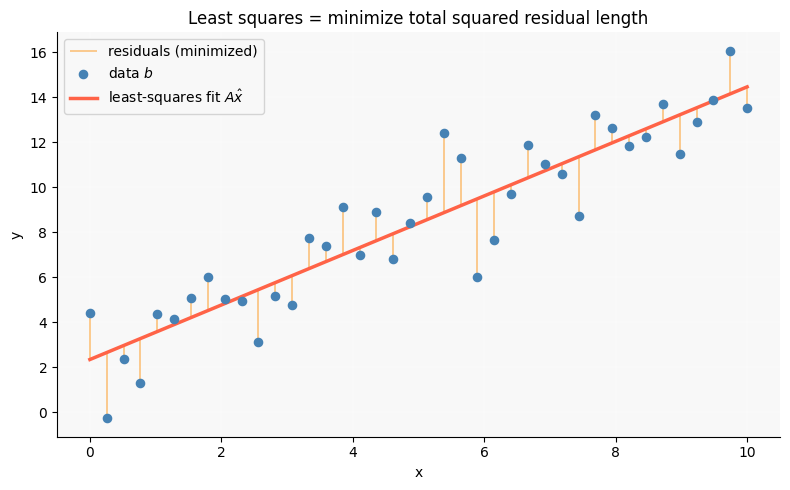

In [10]:
# --- visualize: fitted line + residuals as vertical drops to the column-space projection
fig, ax = plt.subplots(figsize=(8, 5))
xx = np.linspace(0, 10, 100)
yy = w_qr[0] + w_qr[1] * xx
fit = A @ w_qr

ax.vlines(x_data, np.minimum(y_data, fit), np.maximum(y_data, fit),
          color=PALETTE["orange"], alpha=0.5, lw=1.2, label="residuals (minimized)")
ax.scatter(x_data, y_data, s=35, color=PALETTE["blue"], zorder=3, label="data $b$")
ax.plot(xx, yy, color=PALETTE["red"], lw=2.5, label="least-squares fit $A\\hat{x}$")
ax.set(title="Least squares = minimize total squared residual length",
       xlabel="x", ylabel="y")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 8 · Under-determined systems → **least-norm**

Now flip the shape: $A$ is $m \times n$ with $m < n$ (a **wide** matrix — fewer equations
than unknowns). Now there are *infinitely many* exact solutions to $Ax = b$: the solution
set is a whole flat (an affine subspace). We need a tie-breaker.

The natural one: among all exact solutions, pick the **smallest** one (minimum Euclidean
norm). This is the **least-norm** solution:

$$\hat{x} = \arg\min_x \|x\|_2^2 \quad\text{subject to}\quad Ax = b.$$

### Deriving it with a Lagrangian

Constrained optimization → Lagrange multipliers $\lambda$:

$$\mathcal{L}(x,\lambda) = x^\top x + \lambda^\top (A x - b).$$

$$\nabla_x \mathcal{L} = 2x + A^\top \lambda = 0 \;\Longrightarrow\; x = -\tfrac{1}{2}A^\top \lambda.$$

Substitute back into $Ax=b$:

$$A\big(-\tfrac{1}{2}A^\top\lambda\big) = b \;\Longrightarrow\; \lambda = -2\,(AA^\top)^{-1}b,$$

$$\boxed{\hat{x} = A^\top (A A^\top)^{-1} b}.$$

> **Key insight:** Notice the form $x = A^\top(\dots)$. It says the minimum-norm solution
> lives entirely in the **row space** of $A$ — it has *zero* wasted component in the null
> space. Geometrically: from the origin, drop a perpendicular onto the solution flat; the
> foot of that perpendicular is the shortest solution.

> 🎯 **Quant reminder.** Over-determined ↔ $(A^\top A)^{-1}A^\top$ (left pseudo-inverse),
> under-determined ↔ $A^\top(AA^\top)^{-1}$ (right pseudo-inverse). Both are special cases
> of the **Moore–Penrose pseudo-inverse** `np.linalg.pinv`. Knowing which formula goes with
> which shape is a frequent quick-fire question.

In [11]:
# under-determined: 1 equation, 2 unknowns ->  a1*x1 + a2*x2 = b
A = np.array([[1.0, 2.0]])     # 1 x 2 (wide)
b = np.array([2.0])

x_ln = A.T @ np.linalg.solve(A @ A.T, b)   # least-norm formula
print("least-norm solution :", x_ln)
print("satisfies Ax=b?     :", np.allclose(A @ x_ln, b))
print("matches pinv @ b?   :", np.allclose(x_ln, np.linalg.pinv(A) @ b))

# compare against another valid (non-minimal) solution
x_other = np.array([2.0, 0.0])             # also satisfies x1 + 2 x2 = 2
print("\n||least-norm x||    :", np.linalg.norm(x_ln))
print("||other valid  x||  :", np.linalg.norm(x_other), " (larger -> not chosen)")

least-norm solution : [0.4 0.8]
satisfies Ax=b?     : True
matches pinv @ b?   : True

||least-norm x||    : 0.894427190999916
||other valid  x||  : 2.0  (larger -> not chosen)


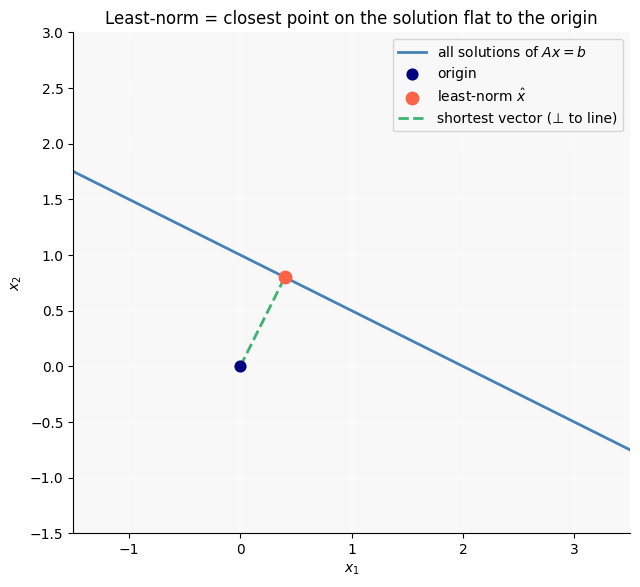

In [12]:
# --- picture: the solution line, the origin, and the shortest vector to it
fig, ax = plt.subplots(figsize=(6.5, 6.5))
t = np.linspace(-2, 4, 100)
# parametrize the solution line x1 + 2 x2 = 2  ->  points (2 - 2s, s)
line = np.array([2 - 2*t, t])
ax.plot(line[0], line[1], color=PALETTE["blue"], lw=2, label="all solutions of $Ax=b$")
ax.scatter([0], [0], color=PALETTE["navy"], s=60, zorder=3, label="origin")
ax.scatter(x_ln[0], x_ln[1], color=PALETTE["red"], s=80, zorder=3,
           label="least-norm $\\hat{x}$")
ax.plot([0, x_ln[0]], [0, x_ln[1]], color=PALETTE["green"], lw=2, ls="--",
        label="shortest vector (⊥ to line)")
ax.set(title="Least-norm = closest point on the solution flat to the origin",
       xlabel="$x_1$", ylabel="$x_2$", xlim=(-1.5, 3.5), ylim=(-1.5, 3))
ax.set_aspect("equal"); ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 9 · Conditioning — why "correct" math gives wrong answers

The **condition number** $\kappa(A) = \sigma_{\max}/\sigma_{\min}$ (ratio of largest to
smallest singular value) measures how much $A$ *amplifies* errors. A large $\kappa$ means
tiny perturbations in $b$ cause huge swings in $x$ — the problem is **ill-conditioned**.

Here's the punchline for least squares. The normal equations use $A^\top A$, and

$$\kappa(A^\top A) = \kappa(A)^2.$$

**Forming $A^\top A$ squares the condition number** — you can lose *twice* as many digits
of accuracy. QR works with $A$ directly (via the well-behaved orthogonal $Q$), so it keeps
$\kappa(A)$, not its square.

> **Key insight:** This is THE reason practitioners solve least squares with QR (or SVD),
> not the textbook normal equations. The normal equations are mathematically correct but
> numerically reckless on ill-conditioned data.

> 🎯 **Quant reminder.** *"You have a near-collinear design matrix — what breaks, and what
> do you do?"* Answer: $A^\top A$ becomes nearly singular, $\kappa$ blows up, normal
> equations lose precision → use QR/SVD, or **regularize** (ridge, next section). This is a
> high-signal answer that separates candidates.

Let's *measure* the accuracy gap on a deliberately ill-conditioned problem.

In [13]:
# build an ill-conditioned tall matrix using a Vandermonde-style design (near-collinear)
m, n = 50, 8
t = np.linspace(0, 1, m)
A = np.vander(t, n, increasing=True)     # columns 1, t, t^2, ... -> highly collinear
x_true = rng.normal(size=n)
b = A @ x_true                            # exact RHS (no noise) -> we know the answer

kA  = np.linalg.cond(A)
kAtA = np.linalg.cond(A.T @ A)
print(f"cond(A)      = {kA:.3e}")
print(f"cond(A^T A)  = {kAtA:.3e}   (≈ cond(A)^2 = {kA**2:.3e})")

# solve via normal equations vs QR, compare error to the known x_true
x_normal = np.linalg.solve(A.T @ A, A.T @ b)
Q, R = qr_gram_schmidt(A)
x_qr = back_sub(R, Q.T @ b)

print(f"\nnormal-equation error ||x - x_true|| : {np.linalg.norm(x_normal - x_true):.3e}")
print(f"QR             error ||x - x_true|| : {np.linalg.norm(x_qr - x_true):.3e}")
print("\n-> QR recovers the true coefficients far more accurately.")

cond(A)      = 1.108e+05
cond(A^T A)  = 1.229e+10   (≈ cond(A)^2 = 1.229e+10)

normal-equation error ||x - x_true|| : 3.187e-07
QR             error ||x - x_true|| : 1.410e-07

-> QR recovers the true coefficients far more accurately.


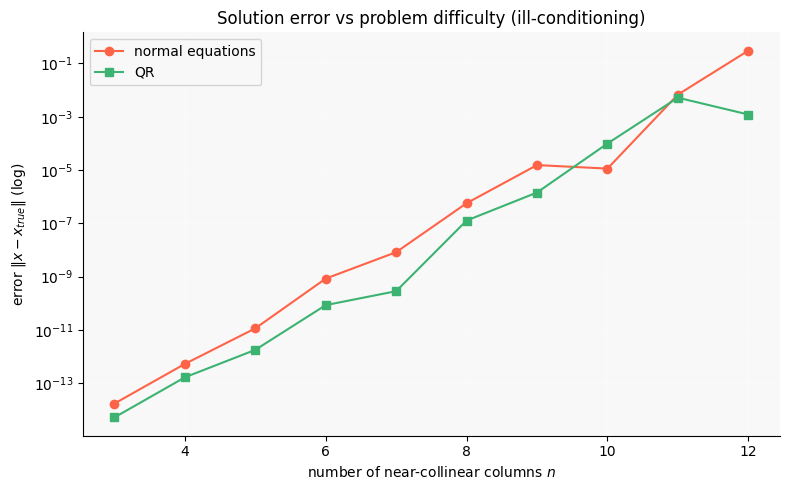

In [14]:
# how the error grows as we make the problem more ill-conditioned (more columns)
ns = range(3, 13)
err_ne, err_qr, conds = [], [], []
for n in ns:
    A = np.vander(t, n, increasing=True)
    xt = rng.normal(size=n)
    b = A @ xt
    conds.append(np.linalg.cond(A))
    err_ne.append(np.linalg.norm(np.linalg.solve(A.T @ A, A.T @ b) - xt))
    Qn, Rn = qr_gram_schmidt(A)
    err_qr.append(np.linalg.norm(back_sub(Rn, Qn.T @ b) - xt))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(list(ns), err_ne, "o-", color=PALETTE["red"], label="normal equations")
ax.semilogy(list(ns), err_qr, "s-", color=PALETTE["green"], label="QR")
ax.set(title="Solution error vs problem difficulty (ill-conditioning)",
       xlabel="number of near-collinear columns $n$", ylabel="error $\\|x-x_{true}\\|$ (log)")
ax.legend(); ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

---
## 10 · Taming ill-conditioning: ridge regularization (interactive)

When $A^\top A$ is nearly singular, another fix is to **add a small ridge** $\lambda I$:

$$\hat{x}_\lambda = (A^\top A + \lambda I)^{-1} A^\top b.$$

The $\lambda I$ term lifts every eigenvalue of $A^\top A$ by $\lambda$, pulling the smallest
ones away from zero — it *improves the conditioning* at the cost of a little bias. As
$\lambda$ grows, the solution shrinks toward zero (smaller $\|\hat{x}\|$) but the residual
$\|A\hat{x}-b\|$ grows. That trade-off is the heart of regularization.

Drag the slider to feel the trade-off. (If `ipywidgets` isn't available, a static
sweep is plotted instead.)

> 🎯 **Quant reminder.** Ridge regression *is* "regularized least squares." Interviewers
> like: *"What does adding $\lambda I$ do geometrically/numerically?"* → it conditions the
> problem and trades variance for bias.

In [15]:
# ill-conditioned least-squares problem with noise
m, n = 50, 8
t = np.linspace(0, 1, m)
A = np.vander(t, n, increasing=True)
x_true = rng.normal(size=n)
b = A @ x_true + rng.normal(scale=0.01, size=m)

def ridge_solve(lam):
    return np.linalg.solve(A.T @ A + lam * np.eye(n), A.T @ b)

def plot_ridge(log_lam=-6.0):
    lam = 10.0 ** log_lam
    x = ridge_solve(lam)
    res = np.linalg.norm(A @ x - b)
    nrm = np.linalg.norm(x)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(range(n), x_true, width=0.4, color=PALETTE["blue"], label="true coefs", align="edge")
    ax.bar(np.arange(n) + 0.4, x, width=0.4, color=PALETTE["orange"],
           label=f"ridge λ=1e{log_lam:.1f}", align="edge")
    ax.set(title=f"residual ‖Ax-b‖={res:.3f}   solution norm ‖x‖={nrm:.2f}",
           xlabel="coefficient index", ylabel="value")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(plot_ridge, log_lam=FloatSlider(min=-8, max=2, step=0.5, value=-6,
                                             description="log10 λ"))
except Exception:
    print("ipywidgets unavailable -> static sweep")
    for ll in [-8, -4, 0, 2]:
        plot_ridge(ll)

interactive(children=(FloatSlider(value=-6.0, description='log10 λ', max=2.0, min=-8.0, step=0.5), Output()), …

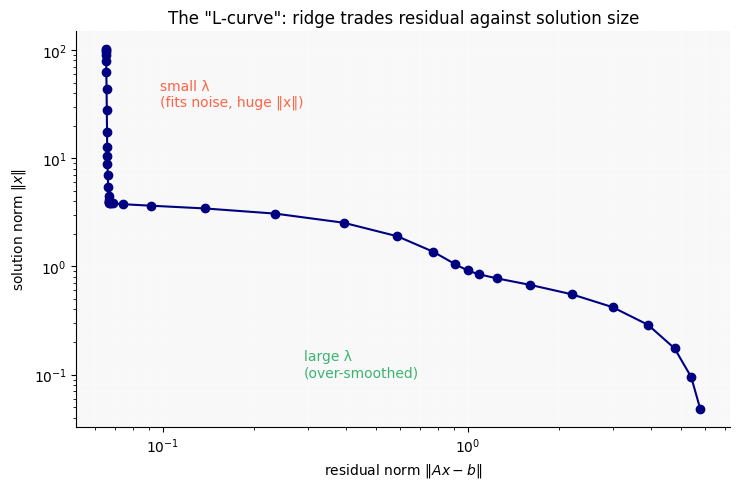

In [16]:
# the classic trade-off curve: solution norm vs residual norm as lambda sweeps (L-curve)
lams = np.logspace(-10, 3, 40)
res_norms = [np.linalg.norm(A @ ridge_solve(l) - b) for l in lams]
sol_norms = [np.linalg.norm(ridge_solve(l)) for l in lams]

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(res_norms, sol_norms, "o-", color=PALETTE["navy"])
ax.set(title='The "L-curve": ridge trades residual against solution size',
       xlabel="residual norm $\\|Ax-b\\|$", ylabel="solution norm $\\|x\\|$")
ax.annotate("small λ\n(fits noise, huge ‖x‖)", xy=(res_norms[0], sol_norms[0]),
            xytext=(res_norms[0]*1.5, sol_norms[0]*0.3), color=PALETTE["red"])
ax.annotate("large λ\n(over-smoothed)", xy=(res_norms[-1], sol_norms[-1]),
            xytext=(res_norms[-1]*0.05, sol_norms[-1]*2), color=PALETTE["green"])
ax.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

---
## 11 · Summary

You now have the full toolkit: three factorizations, three system shapes, and the
numerical judgment to pick the right tool.

| Concept | Key Idea |
|---|---|
| **Why factorize** | Don't invert. Factor once ($\mathcal{O}(n^3)$), reuse for each new $b$ ($\mathcal{O}(n^2)$). |
| **Triangular solve** | Forward/back substitution — the cheap payoff every factorization cashes in. |
| **LU ($PA=LU$)** | Gaussian elimination with the multipliers remembered; partial pivoting for stability. The general-purpose square solver. |
| **Cholesky ($M=LL^\top$)** | 2× faster LU for SPD matrices. Its success/failure *is* the positive-definiteness test. Powers correlated-normal sampling. |
| **QR ($A=QR$)** | Orthonormalize the columns (Gram–Schmidt). Orthogonal $Q$ preserves length → stable least squares. |
| **Square system** | Unique solution. LU by default, Cholesky if SPD, QR if ill-conditioned. |
| **Over-determined (least squares)** | $m>n$, no exact solution → minimize $\|Ax-b\|^2$. Normal equations $A^\top A\hat{x}=A^\top b$ = projecting $b$ onto the column space. |
| **Under-determined (least-norm)** | $m<n$, infinitely many solutions → pick the smallest: $\hat{x}=A^\top(AA^\top)^{-1}b$, lives in the row space. |
| **Pseudo-inverse** | Left $(A^\top A)^{-1}A^\top$ (tall) and right $A^\top(AA^\top)^{-1}$ (wide) are the two faces of `np.linalg.pinv`. |
| **Conditioning** | $\kappa(A^\top A)=\kappa(A)^2$ → normal equations lose accuracy. Prefer QR/SVD; regularize with ridge $\lambda I$. |

### 🎯 Quant interview cheat-sheet
- *"Why not invert the matrix?"* → wasteful + unstable; factor-and-solve instead.
- *"Derive OLS."* → geometry (orthogonal projection) **and** calculus (∇ of $\|Ax-b\|^2$ = 0) → normal equations.
- *"Check positive-definiteness / sample correlated Gaussians?"* → Cholesky ($\Sigma=LL^\top$, then $x=Lz$).
- *"Least squares with collinear features — what breaks?"* → $\kappa(A^\top A)=\kappa(A)^2$ blows up; use QR/SVD or ridge.
- *"Over- vs under-determined formulas?"* → left vs right pseudo-inverse.

> **The one-liner to remember:** *A factorization turns a hard problem ($Ax=b$) into a
> chain of trivial triangular/orthogonal problems — and choosing the factorization is
> really about respecting the matrix's structure and its conditioning.*